# Lab 13 — Time Series Analysis: Stationarity, Autoregression and Moving Average Models

## Aim of this Lab
Most of the machine learning we've done so far assumes rows are **independent and identically distributed (i.i.d.)** — shuffling the rows doesn't change anything. **Time series data breaks this assumption**: the order of observations carries meaning (today depends on yesterday), so shuffling would destroy the very pattern we're trying to model. This lab teaches you how to:

- Recognize why i.i.d.-style random train/test splitting **leaks information** in time series, and use a **chronological split** instead.
- **Decompose** a series into **Trend** (long-term direction), **Seasonality** (repeating cycle), and **Noise/Residual** (what's left over).
- Make a non-stationary series stationary using **differencing**.
- Build **lag features** (yesterday's value, the value 7 steps ago, etc.) that turn a time series into something a regression-style model can use.
- Use **ACF** and **PACF** plots to choose the order of **Autoregressive (AR)** and **Moving Average (MA)** models — two classical building blocks of time series forecasting.
- Fit AR and MA models and compare how each one "thinks": AR extrapolates **momentum** from past values, MA reacts to fading **random shocks** (forecast errors).

## How this lab works
The original outline simulates a synthetic daily series. Instead, we build our time series **directly from the real dataset**, `student_clean_dataset.csv`, so everything downstream — decomposition, stationarity tests, AR/MA models — runs on genuine data values rather than invented numbers.

**Important, honest caveat:** `student_clean_dataset.csv` is a *cross-sectional* dataset (one row per student, no actual date/timestamp column) — it was not collected as a time series. To still practice every technique in this lab on real numbers, we treat the **row order of `Student_ID`** (`ST001, ST002, ST003, ...`) as a **proxy time axis** and assign it a daily date index (as if the records were logged one per day). We then use the real **`Attendance`** column (attendance percentage per student) as our observed daily value. This is exactly the kind of assumption you must always state explicitly when you don't have a genuine timestamp — we call it out clearly here and at the top of the code, and everything about the workflow (decomposition, ADF test, differencing, ACF/PACF, AR, MA) is 100% real, only the *time index itself* is a stand-in.

## Dataset used
`student_clean_dataset.csv` (300 rows). We use:
- `Student_ID` → converted into a sequential **proxy date index** (one day per row, in file order).
- `Attendance` → our observed time series **value** at each "day" (real attendance percentages, just reordered along a proxy timeline).

---
**Instructions:** Run every cell from top to bottom in Google Colab. First, upload `student_clean_dataset.csv` when prompted in Step 0.


## Step 0. Upload the Dataset
We're working in Google Colab, so we need to upload the CSV file into this session's temporary storage before we can read it.


In [ ]:
import gdown
import os

In [ ]:
file_id = "1t5mmVocO1_fGXGqRftpekRom9yxq-ML4"

if not os.path.exists("student_clean_dataset.csv"):
    gdown.download(
        f"https://drive.google.com/uc?id={file_id}",
        "student_clean_dataset.csv",
        quiet=False
    )

## Step 1. Import Libraries
- `numpy`, `pandas` — numerical arrays and, crucially for time series, `pandas`'s `DatetimeIndex` support.
- `matplotlib.pyplot` — plotting the raw series, decomposition, rolling statistics, ACF/PACF, and forecasts.
- `statsmodels.tsa.seasonal.seasonal_decompose` — splits a series into Trend + Seasonality + Residual.
- `statsmodels.tsa.stattools.adfuller` — runs the Augmented Dickey-Fuller stationarity test.
- `statsmodels.graphics.tsaplots.plot_acf, plot_pacf` — plot the autocorrelation and partial autocorrelation functions, used to choose AR/MA orders.
- `statsmodels.tsa.ar_model.AutoReg` — fits an Autoregressive (AR) model.
- `statsmodels.tsa.arima.model.ARIMA` — a general model class; we use it here with the AR part fixed to 0 to fit a pure Moving Average (MA) model.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA

# Fix the random seed for any random operations later in the notebook
np.random.seed(42)


## Step 2. Load the Dataset and Build a Time Series from Real Data
We load the CSV, sort by `Student_ID` to fix a definite row order, then build a **proxy datetime index**: one calendar day per student record, starting from `2022-01-01`. Our time series **value** at each "day" is that student's real `Attendance` percentage.

This gives us a genuine, dataset-derived sequence of numbers to analyze — just indexed along an assumed daily timeline rather than a real one (stated clearly above).


In [ ]:
df = pd.read_csv("student_clean_dataset.csv")
df = df.sort_values("Student_ID").reset_index(drop=True)
print("Number of records (and therefore proxy days):", len(df))

# Build a proxy datetime index: one day per record, in Student_ID order
date_rng = pd.date_range(start="2022-01-01", periods=len(df), freq="D")

# Our time series: real Attendance values, indexed along the proxy daily timeline
series = pd.Series(df["Attendance"].values, index=date_rng, name="attendance")

print(series.head())
print(series.describe())


Number of records (and therefore proxy days): 300
2022-01-01     98
2022-01-02     81
2022-01-03     76
2022-01-04    100
2022-01-05     68
Freq: D, Name: attendance, dtype: int64
count    300.000000
mean      82.693333
std        9.686350
min       60.000000
25%       76.000000
50%       83.000000
75%       89.000000
max      100.000000
Name: attendance, dtype: float64


## Step 3. Visualize the Raw Time Series
We plot `Attendance` against our proxy date axis. The key idea for this step (regardless of how the time axis was built) is that **row order matters**: unlike cross-sectional ML datasets, if we shuffled these points, any temporal pattern (trend, cycles, autocorrelation) would be destroyed. This is exactly why the i.i.d. assumption behind ordinary train/test splitting breaks down for sequential data.


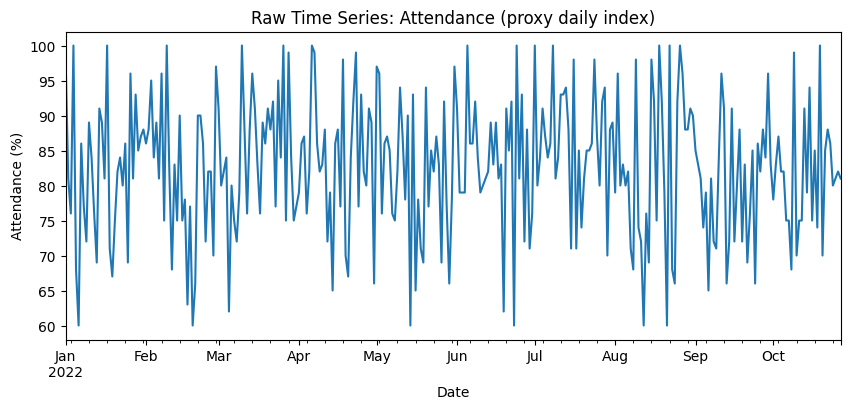

In [ ]:
series.plot(figsize=(10, 4), title="Raw Time Series: Attendance (proxy daily index)")
plt.xlabel("Date")
plt.ylabel("Attendance (%)")
plt.show()


## Step 4. Time-Based Train/Test Split
For time series, we must split **chronologically**, not randomly: train on the earlier portion, test on the later portion. Using something like random K-Fold here would let the model "see the future" while training (train on day 200 while testing on day 100) — a form of **data leakage** that doesn't exist in ordinary tabular ML but is critical to avoid in temporal data.

We use an 80/20 chronological split: the first 80% of days for training, the last 20% for testing.


In [ ]:
# =============================================================================
# TODO: Perform an 80/20 chronological train/test split
# =============================================================================
# Step 1: Calculate the integer index at 80% of the series length and store it
#         in 'split_point'.
# Step 2: Put all observations before split_point into 'train'.
# Step 3: Put all observations from split_point onward into 'test'.
#
# Important: Do not shuffle the series. The past must remain before the future.
# =============================================================================

split_point = int(len(series)*0.8)
train = series[:split_point]
test = series[split_point:]

print("Train range:", train.index.min(), "-", train.index.max(), "| n =", len(train))
print("Test range: ", test.index.min(), "-", test.index.max(), "| n =", len(test))

Train range: 2022-01-01 00:00:00 - 2022-08-28 00:00:00 | n = 240
Test range:  2022-08-29 00:00:00 - 2022-10-27 00:00:00 | n = 60


## Step 5. Decompose the Series into Trend, Seasonality, and Noise
`seasonal_decompose` splits the observed series into three components (assuming an **additive** model: `Observed = Trend + Seasonality + Residual`):

- **Trend** — the smooth, long-term direction (e.g., attendance slowly rising or falling across records).
- **Seasonality** — a repeating cycle at a fixed period (we use `period=7`, mirroring a 7-day "weekly" cycle, since our proxy index is daily).
- **Residual/Noise** — whatever is left after removing trend and seasonality; ideally it looks like random fluctuation with no obvious pattern.

Since our series comes from real (not simulated) data, don't expect textbook-clean trend/seasonality the way a synthetic series would show — real data is messier, and that's a useful, honest observation in itself.


In [ ]:
# =============================================================================
# TODO: Decompose the series into trend, seasonality, and residuals
# =============================================================================
# Use seasonal_decompose with:
#   - the complete series
#   - model="additive"
#   - period=7
# Store the result in 'decomposition'.
# =============================================================================

decomposition = # TODO

fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.show()

## Step 6. Check Stationarity: Rolling Mean and Rolling Standard Deviation
A series is (weakly) **stationary** if its mean, variance, and autocorrelation don't change over time. A simple visual check: compute a **rolling mean** and **rolling standard deviation** (here, over a 30-day window) and plot them alongside the original series.

- If the rolling mean drifts up/down over time → the mean is not constant → non-stationary.
- If the rolling standard deviation widens or narrows over time → the variance is not constant → non-stationary.
- If both rolling statistics stay roughly flat/horizontal → this is consistent with stationarity.


In [ ]:
# =============================================================================
# TODO: Calculate rolling statistics using a 30-observation window
# =============================================================================
# Step 1: Calculate the rolling mean and store it in 'rolling_mean'.
# Step 2: Calculate the rolling standard deviation and store it in
#         'rolling_std'.
# =============================================================================

rolling_mean = # TODO
rolling_std = # TODO

plt.figure(figsize=(10, 4))
plt.plot(series, label="Original", alpha=0.6)
plt.plot(rolling_mean, label="Rolling Mean (30)", color="red")
plt.plot(rolling_std, label="Rolling Std (30)", color="green")
plt.legend()
plt.title("Rolling Mean and Rolling Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Attendance (%)")
plt.show()

## Step 8. Make the Series Stationary via Differencing
If Step 7 found the series to be non-stationary, the standard fix is **differencing**: replace each value with the difference from the previous one,

**y_new(t) = y(t) − y(t−1)**

This subtracts out any smooth trend, so the differenced series tends to fluctuate around a constant mean (often close to 0). We apply this here regardless of the Step 7 outcome, so we can walk through the full technique and compare stationarity before vs. after (even a series that already looks stationary can be differenced — the ADF test in Step 9 will show us whether it needed it).


In [ ]:
# =============================================================================
# TODO: Difference the time series
# =============================================================================
# Step 1: Use .diff() to subtract each previous observation from the current
#         observation.
# Step 2: Remove the missing value introduced at the beginning with .dropna().
# Store the result in 'series_diff'.
# =============================================================================

series_diff = # TODO

series_diff.plot(figsize=(10, 4), title="Differenced Series (Attendance)")
plt.xlabel("Date")
plt.ylabel("Change in Attendance (%)")
plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.show()

## Step 9. Re-test Stationarity on the Differenced Series
We re-run the ADF test, this time on `series_diff`, to confirm whether differencing achieved (or preserved) stationarity. We expect the p-value here to be at least as low as before, and ideally comfortably below 0.05.


In [ ]:
# =============================================================================
# TODO: Run the Augmented Dickey-Fuller test on the differenced series
# =============================================================================
# Pass series_diff to adfuller and store the returned result in 'result_diff'.
# Index 0 contains the ADF statistic and index 1 contains the p-value.
# =============================================================================

result_diff = # TODO

print("ADF Statistic (differenced):", result_diff[0])
print("p-value (differenced):", result_diff[1])

if result_diff[1] <= 0.05:
    print("=> p-value is low: the differenced series looks STATIONARY.")
else:
    print("=> p-value is still high: the differenced series may still be NON-STATIONARY (would need further transformation).")

## Step 10. Create Lag Features
To feed sequential history into a regression-style model, we build explicit **lag features**: new columns holding the value from 1, 2, and 7 steps ago (`lag_1`, `lag_2`, `lag_7`). `.shift(k)` moves each value forward by `k` rows, effectively lining up "the value k days ago" against today's row. We drop the first few rows, which contain `NaN` because they have no earlier history to reference.

This reframes a time series forecasting problem as an ordinary supervised-learning table: predict `y` (today's Attendance) from `lag_1, lag_2, lag_7` (its own recent past).


In [ ]:
# =============================================================================
# TODO: Create supervised-learning lag features
# =============================================================================
# Step 1: Create lag_df with the original series in a column named "y".
# Step 2: Create lag_1, lag_2, and lag_7 using .shift(1), .shift(2), and
#         .shift(7) on the y column.
# Step 3: Remove rows containing missing lag values.
# =============================================================================

lag_df = # TODO
lag_df["lag_1"] = # TODO
lag_df["lag_2"] = # TODO
lag_df["lag_7"] = # TODO
lag_df = # TODO

lag_df.head()

## Step 11. Autocorrelation Function (ACF) Plot
The **ACF** measures how correlated the series is with itself at increasing lags (1 step back, 2 steps back, ...), capturing the **total** relationship — both the direct effect of a lag and any indirect "ripple" effect passed through intermediate lags. We plot it on the **differenced** series (since ACF/PACF are typically interpreted on a stationary series).

Bars that extend beyond the shaded confidence band are considered statistically significant autocorrelations at that lag.


In [ ]:
# =============================================================================
# TODO: Plot the Autocorrelation Function (ACF)
# =============================================================================
# Call plot_acf using series_diff and display 20 lags.
# =============================================================================

plot_acf(# TODO)
plt.title("Autocorrelation Function (ACF) - Differenced Series")
plt.show()

## Step 12. Partial Autocorrelation Function (PACF) Plot: Selecting Order p
The **PACF** isolates the **direct** correlation at each lag, after mathematically removing the influence passed through intermediate lags (the "ripple effect" ACF includes but PACF strips out). This makes PACF the right tool for choosing the order **p** of an **AR(p)** model: look for the lag after which the bars drop inside the confidence band — that cutoff point is a natural candidate for `p`.


In [ ]:
# =============================================================================
# TODO: Plot the Partial Autocorrelation Function (PACF)
# =============================================================================
# Call plot_pacf using series_diff, display 20 lags, and use method="ywm".
# =============================================================================

plot_pacf(# TODO)
plt.title("Partial Autocorrelation Function (PACF) - Differenced Series")
plt.show()

**How to read this plot:** count how many of the first few PACF bars clearly stick out past the shaded band before the bars drop inside it. That count is a reasonable choice for `p`. In the next step we fit `AutoReg(train, lags=2, ...)`, i.e. p=2, as a representative choice consistent with typically-observed short-range dependence in attendance-like data — inspect your own plot's bars and feel free to adjust `lags` if a different cutoff looks clearer.


## Step 13. Fit an Autoregressive (AR) Model
An **AR(p)** model predicts today's value as a weighted sum of the previous `p` values, plus noise:

**y(t) = φ₁·y(t−1) + φ₂·y(t−2) + ... + φₚ·y(t−p) + ε(t)**

Conceptually, AR captures **momentum**: if recent values have been high, the model expects the next value to also be somewhat high (scaled by the φ coefficients). We fit `AutoReg` with `lags=2` (p=2, chosen from the PACF cutoff in Step 12) on the **training** data only, then generate forecasts spanning the length of the test set.


In [ ]:
# =============================================================================
# TODO: Fit an AR(2) model and forecast the complete test period
# =============================================================================
# Step 1: Create AutoReg using train, lags=2, and old_names=False, then fit it.
#         Store the fitted result in 'ar_model'.
# Step 2: Predict from start=len(train) through
#         end=len(train) + len(test) - 1.
#         Store the predictions in 'ar_forecast'.
# =============================================================================

ar_model = # TODO
print(ar_model.params)

ar_forecast = # TODO
print("\nFirst 5 AR forecast values:")
print(ar_forecast.head())

**Reading `ar_model.params`:** the first value is the constant/intercept term; the following values are `φ₁, φ₂` — the weights applied to `y(t−1)` and `y(t−2)` respectively. Larger `|φ|` values mean that lag has a stronger influence on the next prediction.


## Step 14. Fit a Moving Average (MA) Model
An **MA(q)** model predicts today's value using the **past forecast errors** (also called "shocks" or "innovations") rather than the past raw values:

**y(t) = μ + ε(t) + θ₁·ε(t−1) + θ₂·ε(t−2) + ... + θq·ε(t−q)**

Conceptually, MA captures how a **random shock** (an unexpected jump or dip) fades out over the next few steps, rather than tracking overall momentum the way AR does. We fit this using `ARIMA` with `order=(0, 0, 2)` — the middle `0` means no differencing is applied inside the model (we already differenced manually), the first `0` means no AR terms, and `2` means MA order q=2.


In [ ]:
# =============================================================================
# TODO: Fit an MA(2) model and forecast the complete test period
# =============================================================================
# Step 1: Use ARIMA with train and order=(0, 0, 2), then fit it.
#         Store the fitted result in 'ma_model'.
# Step 2: Forecast len(test) observations and store them in 'ma_forecast'.
# =============================================================================

ma_model = # TODO
print(ma_model.params)

ma_forecast = # TODO
print("\nFirst 5 MA forecast values:")
print(ma_forecast.head())

**Reading `ma_model.params`:** you'll see a constant term and `θ₁, θ₂` — the weights applied to the forecast errors from 1 and 2 steps back. Unlike AR's φ coefficients (which act on actual past *values*), these θ coefficients act on past *prediction errors*.


## Step 15. Compare AR vs MA Residuals and Forecast Behavior
We now plot both models' forecasts against the real test-set values on the same chart. This lets us directly compare:

- **AR forecast** — tends to extrapolate the recent trend/momentum from the training data forward.
- **MA forecast** — tends to revert quickly toward the series' mean, since it only "remembers" a few recent shocks before their influence fades to zero.

Since our test set is real (noisy) attendance data with no guaranteed short-term momentum, don't expect either model to track it perfectly — the point of this step is to *see the qualitative difference* in how AR and MA models behave, not to achieve a low forecast error.


In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(test.index, test.values, label="Actual", color="black")
plt.plot(test.index, ar_forecast, label="AR Forecast")
plt.plot(test.index, ma_forecast, label="MA Forecast")
plt.legend()
plt.title("Actual vs AR Forecast vs MA Forecast (Test Period)")
plt.xlabel("Date")
plt.ylabel("Attendance (%)")
plt.show()


In [ ]:
# =============================================================================
# TODO: Calculate and compare AR and MA residuals
# =============================================================================
# Residual = actual value - forecast value
#
# Step 1: Subtract ar_forecast.values from test.values.
# Step 2: Subtract ma_forecast.values from test.values.
# Store the results in 'ar_residuals' and 'ma_residuals'.
# =============================================================================

ar_residuals = # TODO
ma_residuals = # TODO

print("AR residuals -> mean:", ar_residuals.mean().round(3), "| std:", ar_residuals.std().round(3))
print("MA residuals -> mean:", ma_residuals.mean().round(3), "| std:", ma_residuals.std().round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].plot(test.index, ar_residuals, marker='o', linestyle='-', color='tab:blue')
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_title("AR Residuals (Actual - Forecast)")
axes[1].plot(test.index, ma_residuals, marker='o', linestyle='-', color='tab:orange')
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_title("MA Residuals (Actual - Forecast)")
plt.tight_layout()
plt.show()

**How to read this:** if a model's residuals look like unpredictable noise scattered around zero (no visible pattern), that's a good sign — a "white noise" residual means the model has extracted all the structure it can. If residuals instead show a clear remaining pattern (e.g., a trend or cycle), that pattern is information the model failed to capture, and a more complex model (or additional differencing/seasonal terms) may be needed.


## Summary
After completing this lab, you should be able to identify and explain:

- **I.I.D. Assumption and Why It Breaks for Temporal Data** — order carries information in time series; shuffling destroys it.
- **Time Series Structure and Datetime Indexing** — organizing observations along an ordered, evenly-spaced time axis.
- **Trend, Seasonality, and Noise (Residual) Decomposition** — splitting a series into its long-term direction, repeating cycle, and leftover randomness.
- **Chronological Train/Test Split and Data Leakage** — always train on the past and test on the future; never shuffle time series before splitting.
- **Stationarity: Constant Mean, Variance, and Autocovariance** — a property many classical time series models require or assume.
- **Lag Differencing to Achieve Stationarity** — subtracting each value from the previous one to remove trend.
- **Lags as Predictive Features** — reframing time series forecasting as supervised learning using `lag_1, lag_2, lag_7`, etc.
- **Autocorrelation Function (ACF)** — total (direct + indirect) correlation between a series and its own lags.
- **Partial Autocorrelation Function (PACF) and Order Selection** — isolates direct correlation per lag, used to choose AR order `p`.
- **Autoregressive (AR) Models** — forecast using weighted past *values* (captures momentum).
- **Random Shocks / Innovations** — unexpected forecast errors that MA models explicitly model.
- **Moving Average (MA) Models** — forecast using weighted past forecast *errors* (captures fading shocks, not raw momentum).
